In [1]:
from pathlib import Path
from torch.utils.data import Dataset, Subset, DataLoader
import torch
from sklearn.model_selection import train_test_split
import numpy as np
from PIL import Image
import tifffile
import matplotlib.pyplot as plt
import cv2
import torch.nn.functional as F
import numpy as np
import torch.nn as nn

In [2]:
import torch.nn.functional as F

class SiLog(nn.Module):
    def __init__(self, lambd=0.85):
        super().__init__()
        self.lambd = lambd

    def forward(self, pred, target) -> torch.Tensor:
        if isinstance(pred, np.ndarray):
            pred = torch.from_numpy(pred).float()
        if isinstance(target, np.ndarray):
            target = torch.from_numpy(target).float()

        pred   = pred.squeeze()
        target = target.squeeze()

        # resize pred to target resolution if needed
        if pred.shape != target.shape:
            pred = F.interpolate(
                pred.unsqueeze(0).unsqueeze(0),
                size=target.shape, mode="bilinear", align_corners=False
            ).squeeze()

        pred   = pred.flatten()
        target = target.flatten()

        valid_mask = (target > 0) & (pred > 0)
        if valid_mask.sum() == 0:
            return torch.tensor(0.0)

        d = torch.log(pred[valid_mask]) - torch.log(target[valid_mask])
        loss = torch.mean(d ** 2) - self.lambd * (torch.mean(d) ** 2)
        return torch.sqrt(loss)

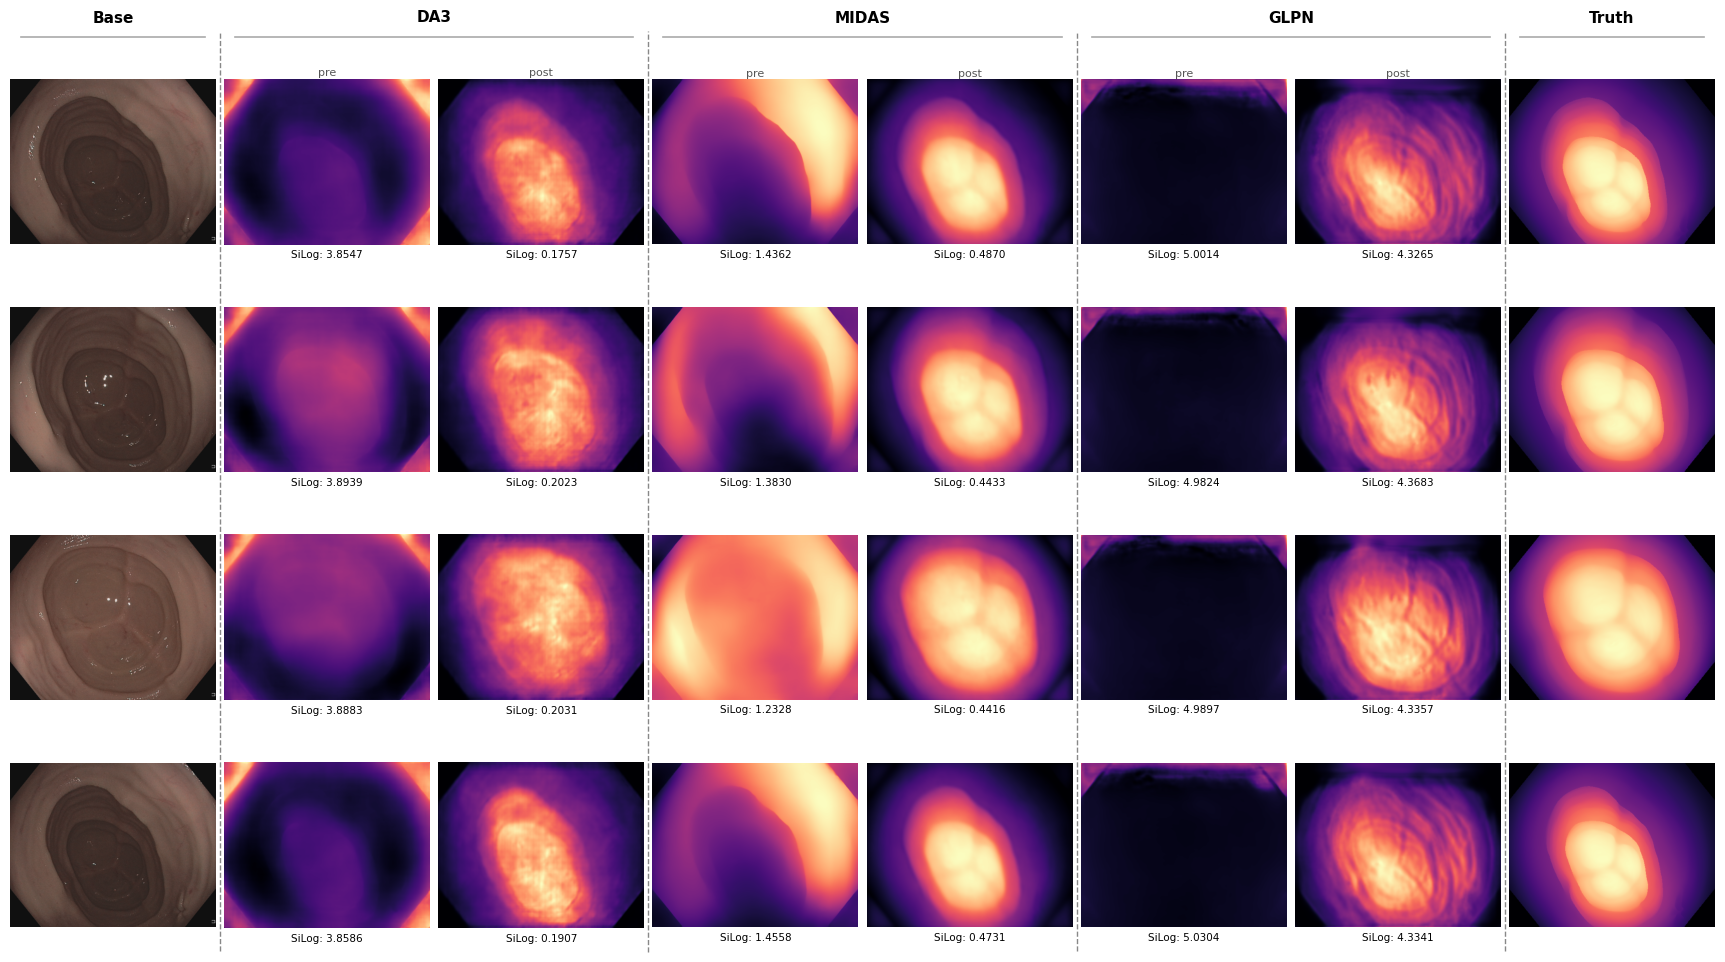

In [3]:
import tifffile as tif
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

def load_folder(folder):
    paths = sorted(Path(folder).glob("*.tiff"))
    return [tif.imread(str(p)) for p in paths]

folders = {
    "base":         load_folder("base"),
    "da3_pre":      load_folder("da3_pre"),
    "da3_post":     load_folder("da3_post"),
    "midas_pre":    load_folder("midas_pre"),
    "midas_post":   load_folder("midas_post"),
    "glpn_pre":     load_folder("glpn_pre"),
    "glpn_post":    load_folder("glpn_post"),
    "ground_truth": load_folder("ground_truth"),
}

# col index mapping
cols     = list(folders.keys())
no_silog = {"base", "ground_truth"}
n_imgs   = 4
cmap     = "magma"
silog_fn = SiLog()

fig, axes = plt.subplots(n_imgs, len(cols), figsize=(22, 12))
plt.subplots_adjust(top=0.82, hspace=0.35, wspace=0.04)

for i in range(n_imgs):
    gt = folders["ground_truth"][i]
    for j, col in enumerate(cols):
        ax  = axes[i, j]
        img = folders[col][i]
        ax.imshow(img, cmap=None if col == "base" else cmap)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        if col not in no_silog:
            with torch.no_grad():
                score = silog_fn(torch.from_numpy(img).float(),
                                 torch.from_numpy(gt).float()).item()
            ax.set_xlabel(f"SiLog: {score:.4f}", fontsize=7.5)

# ── Bottom header row: pre / post sub-labels ─────────────────────────────────
sub_labels = {
    "base":         "",
    "da3_pre":      "pre",
    "da3_post":     "post",
    "midas_pre":    "pre",
    "midas_post":   "post",
    "glpn_pre":     "pre",
    "glpn_post":    "post",
    "ground_truth": "",
}
for j, col in enumerate(cols):
    axes[0, j].set_title(sub_labels[col], fontsize=8, pad=2, color="#555")

# ── Top header row: group labels ──────────────────────────────────────────────
# group definitions: (label, [col_indices])
groups = [
    ("Base",  [0]),
    ("DA3",   [1, 2]),
    ("MIDAS", [3, 4]),
    ("GLPN",  [5, 6]),
    ("Truth", [7]),
]

for label, idxs in groups:
    # span from left edge of first col to right edge of last col
    ax_l = axes[0, idxs[0]]
    ax_r = axes[0, idxs[-1]]

    # get bounding box in figure coords
    fig.canvas.draw()
    bbox_l = ax_l.get_position()
    bbox_r = ax_r.get_position()

    x_center = (bbox_l.x0 + bbox_r.x1) / 2
    y_top    = bbox_l.y1

    fig.text(x_center, y_top + 0.045, label,
             ha="center", va="bottom", fontsize=11, fontweight="bold")

    # underline spanning the group
    line_y = y_top + 0.035
    fig.add_artist(plt.Line2D(
        [bbox_l.x0 + 0.005, bbox_r.x1 - 0.005],
        [line_y, line_y],
        transform=fig.transFigure,
        color="#aaa", linewidth=1.2, clip_on=False
    ))

# ── Vertical dividers between groups ─────────────────────────────────────────
divider_after = [0, 2, 4, 6]   # col indices after which to draw a line

for j in divider_after:
    ax_l = axes[0, j]
    ax_r = axes[-1, j]

    fig.canvas.draw()
    bbox_top = ax_l.get_position()
    bbox_bot = axes[-1, j].get_position()

    x = (bbox_top.x1 + axes[0, j+1].get_position().x0) / 2
    fig.add_artist(plt.Line2D(
        [x, x],
        [bbox_bot.y0 - 0.02, bbox_top.y1 + 0.04],
        transform=fig.transFigure,
        color="#888", linewidth=1.0, linestyle="--", clip_on=False
    ))

plt.savefig("comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
from collections import defaultdict

model_cols = {
    "DA3":   ["da3_pre",   "da3_post"],
    "MIDAS": ["midas_pre", "midas_post"],
    "GLPN":  ["glpn_pre",  "glpn_post"],
}

scores = defaultdict(lambda: defaultdict(list))

for i in range(n_imgs):
    gt = folders["ground_truth"][i]
    for model, variants in model_cols.items():
        for col in variants:
            img   = folders[col][i]
            score = silog_fn(torch.from_numpy(img).float(),
                             torch.from_numpy(gt).float()).item()
            variant = col.split("_")[1]  # "pre" or "post"
            scores[model][variant].append(score)

print(f"{'Model':<8} {'Variant':<8} {'Avg SiLog':>10}")
print("-" * 30)
for model, variants in scores.items():
    for variant, vals in variants.items():
        print(f"{model:<8} {variant:<8} {np.mean(vals):>10.4f}")
    print()

Model    Variant   Avg SiLog
------------------------------
DA3      pre          3.8739
DA3      post         0.1929

MIDAS    pre          1.3770
MIDAS    post         0.4612

GLPN     pre          5.0010
GLPN     post         4.3411

